# **Exp7: Fluid Friction in Pipes**

# Codes for the Graphs of the Data Received

## 6 mm

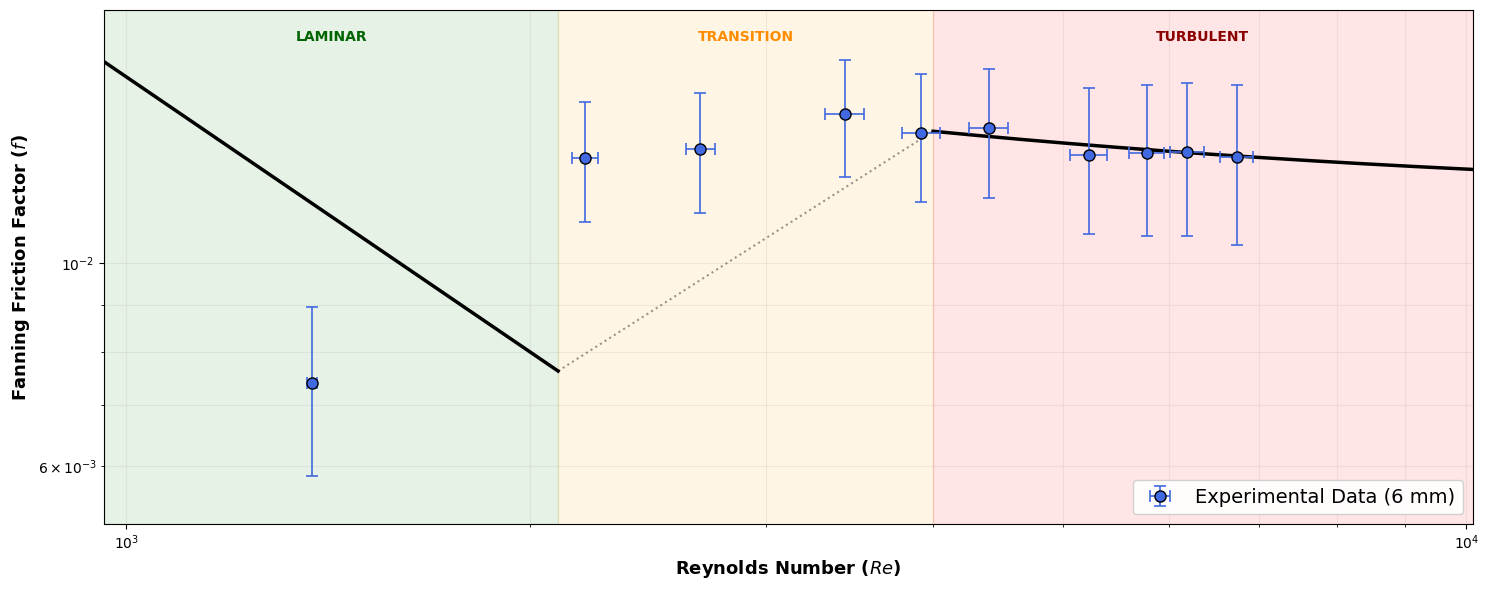

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.lines as mlines

# 1. Load the data
df = pd.read_csv('Data6.csv')
df.columns = [c.strip().replace('δ', 'd') for c in df.columns]

# 2. Physics-based Models
def laminar_model(Re):
    return 16 / Re

def haaland_model(Re, ed):
    term = (ed/3.7)**1.11 + 6.9/Re
    f_darcy = (-1.8 * np.log10(term))**-2
    return f_darcy / 4 

# 3. Fit the turbulent data to find pipe roughness
turb_pts = df[df['Re'] > 3000]
popt, _ = curve_fit(haaland_model, turb_pts['Re'], turb_pts['f'], p0=[0.001])
fitted_ed = popt[0]

# 4. Generate Trendline Segments
LAMINAR_LIMIT = 2100
TURBULENT_START = 4000
x_min, x_max = df['Re'].min() * 0.7, df['Re'].max() * 1.5

Re_lam = np.logspace(np.log10(x_min), np.log10(LAMINAR_LIMIT), 100)
Re_turb = np.logspace(np.log10(TURBULENT_START), np.log10(x_max), 200)
Re_trans = np.logspace(np.log10(LAMINAR_LIMIT), np.log10(TURBULENT_START), 50)

f_lam = laminar_model(Re_lam)
f_turb = haaland_model(Re_turb, fitted_ed)
f_trans = np.logspace(np.log10(f_lam[-1]), np.log10(f_turb[0]), 50)

# 5. Plotting
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xscale('log')
ax.set_yscale('log')

# Background Colors for Regimes
ax.axvspan(x_min, LAMINAR_LIMIT, color='green', alpha=0.1)
ax.axvspan(LAMINAR_LIMIT, TURBULENT_START, color='orange', alpha=0.1)
ax.axvspan(TURBULENT_START, x_max, color='red', alpha=0.1)

# Trendlines (Solid Black)
ax.plot(Re_lam, f_lam, color='black', linewidth=2.5)
ax.plot(Re_turb, f_turb, color='black', linewidth=2.5)
ax.plot(Re_trans, f_trans, color='black', linestyle=':', linewidth=1.5, alpha=0.4)

# Data Points (Treating all as normal experimental points)
ax.errorbar(df['Re'], df['f'], xerr=df['dRe'], yerr=df['df'], 
            fmt='o', color='royalblue', markersize=8, 
            capsize=4, capthick=1.2, elinewidth=1.2, markeredgecolor='black', 
            label='Experimental Data (6 mm)', zorder=10)

# Regime Labels at the top
label_y = 0.94
ax.text(np.sqrt(x_min * LAMINAR_LIMIT), label_y, 'LAMINAR', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkgreen')
ax.text(np.sqrt(LAMINAR_LIMIT * TURBULENT_START), label_y, 'TRANSITION', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkorange')
ax.text(np.sqrt(TURBULENT_START * x_max), label_y, 'TURBULENT', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkred')

# --- REFINED LEGEND (Bottom Right, Data Only) ---
ax.legend(loc='lower right', frameon=True, fontsize=14, facecolor='white', framealpha=0.9)

# Formatting
ax.set_xlim(x_min, x_max)
ax.set_ylim(df['f'].min()*0.7, df['f'].max()*1.3)
ax.set_xlabel('Reynolds Number ($Re$)', fontsize=13, fontweight='bold')
ax.set_ylabel('Fanning Friction Factor ($f$)', fontsize=13, fontweight='bold')
ax.grid(True, which="both", linestyle='-', alpha=0.2)


plt.tight_layout()
plt.show()

## 12 mm

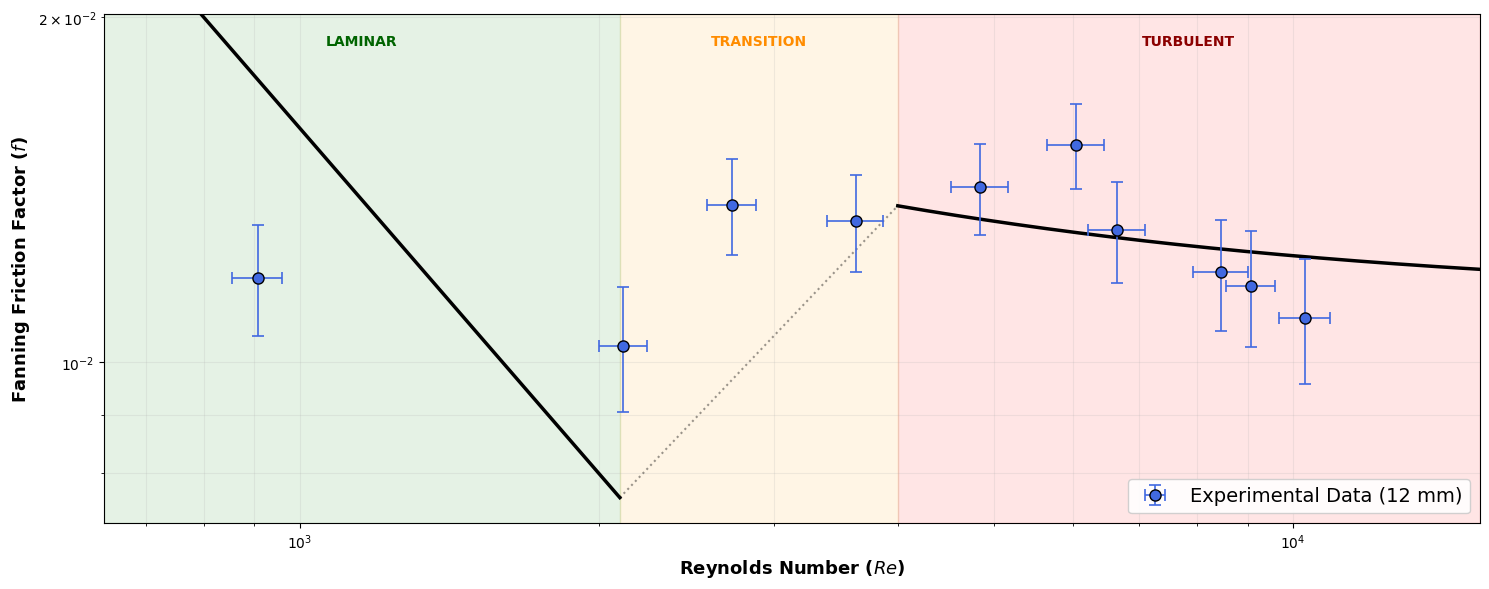

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.lines as mlines

# 1. Load the 12mm data
df = pd.read_csv('Data12.csv')
df.columns = [c.strip() for c in df.columns]

# Ensure column names match your CSV (Re, f, _Re, _f)
x_col, y_col, dx_col, dy_col = 'Re', 'f', '_Re', '_f'

# 2. Physics-based Models
def laminar_model(Re):
    return 16 / Re

def haaland_model(Re, ed):
    # Haaland approximation for Fanning Friction Factor
    term = (ed/3.7)**1.11 + 6.9/Re
    f_darcy = (-1.8 * np.log10(term))**-2
    return f_darcy / 4 

# 3. Fit the turbulent data to find pipe roughness (epsilon/D)
# We use points with Re > 3000 to define the turbulent trend for the 12mm pipe
turbulent_mask = df[x_col] > 3000
turb_pts = df[turbulent_mask]

# Performing the fit
popt, _ = curve_fit(haaland_model, turb_pts[x_col], turb_pts[y_col], p0=[0.001])
fitted_ed = popt[0]

# 4. Generate Trendline Segments
LAMINAR_LIMIT = 2100
TURBULENT_START = 4000
x_min, x_max = df[x_col].min() * 0.7, df[x_col].max() * 1.5

# Ranges for the plot segments
Re_lam = np.logspace(np.log10(x_min), np.log10(LAMINAR_LIMIT), 100)
Re_turb = np.logspace(np.log10(TURBULENT_START), np.log10(x_max), 200)
Re_trans = np.logspace(np.log10(LAMINAR_LIMIT), np.log10(TURBULENT_START), 50)

# Calculate Y-values for black trendlines
f_lam = laminar_model(Re_lam)
f_turb = haaland_model(Re_turb, fitted_ed)
f_trans = np.logspace(np.log10(f_lam[-1]), np.log10(f_turb[0]), 50)

# 5. Plotting
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xscale('log')
ax.set_yscale('log')

# Background Colors for Regimes
ax.axvspan(x_min, LAMINAR_LIMIT, color='green', alpha=0.1)
ax.axvspan(LAMINAR_LIMIT, TURBULENT_START, color='orange', alpha=0.1)
ax.axvspan(TURBULENT_START, x_max, color='red', alpha=0.1)

# Trendlines (Solid Black)
ax.plot(Re_lam, f_lam, color='black', linewidth=2.5)
ax.plot(Re_turb, f_turb, color='black', linewidth=2.5)
ax.plot(Re_trans, f_trans, color='black', linestyle=':', linewidth=1.5, alpha=0.4)

# Data Points (Treating all as normal experimental points with error bars)
ax.errorbar(df[x_col], df[y_col], xerr=df[dx_col], yerr=df[dy_col], 
            fmt='o', color='royalblue', markersize=8, 
            capsize=4, capthick=1.2, elinewidth=1.2, markeredgecolor='black', 
            label='Experimental Data (12 mm)', zorder=10)

# Regime Labels at the top
label_y = 0.94
ax.text(np.sqrt(x_min * LAMINAR_LIMIT), label_y, 'LAMINAR', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkgreen')
ax.text(np.sqrt(LAMINAR_LIMIT * TURBULENT_START), label_y, 'TRANSITION', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkorange')
ax.text(np.sqrt(TURBULENT_START * x_max), label_y, 'TURBULENT', transform=ax.get_xaxis_transform(),
        ha='center', fontweight='bold', color='darkred')

# --- LEGEND (Bottom Right, Data Only) ---
ax.legend(loc='lower right', frameon=True, fontsize=14, facecolor='white', framealpha=0.9)

# Formatting
ax.set_xlim(x_min, x_max)
ax.set_ylim(df[y_col].min()*0.7, df[y_col].max()*1.3)
ax.set_xlabel('Reynolds Number ($Re$)', fontsize=13, fontweight='bold')
ax.set_ylabel('Fanning Friction Factor ($f$)', fontsize=13, fontweight='bold')
ax.grid(True, which="both", linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()